In [1]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
    
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.preprocessing import PowerTransformer


In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D1
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D1['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D1 in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D1 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,8.83,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,19.73,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,13.27,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [13]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 14)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 16)

# Feature Selection with Random Forest

In [17]:
# Setting y 
y_rsf_classifier = clinical_train['event_DFS']

# Define parameters for StratifiedKFold
n_splits = 5
n_repeats = 4

# Initialize variables to store results
all_feature_importances = []

# Perform stratified 5-split 4 times and train Random Forest Classifier for each split
for i in range(n_repeats):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=i)  # Use different random_state for each repeat
    repeat_feature_importances = []
    
    for train_index, test_index in skf.split(X, y_rsf_classifier):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y_rsf_classifier.iloc[train_index], y_rsf_classifier.iloc[test_index]

        # Train Random Forest Classifier
        rf_classifier = RandomForestClassifier(random_state=i)  # You can adjust parameters as needed
        rf_classifier.fit(X_train, y_train)

        # Store feature importances
        repeat_feature_importances.append(rf_classifier.feature_importances_)

    all_feature_importances.append(repeat_feature_importances)

# Convert to numpy array for easier manipulation
all_feature_importances = np.array(all_feature_importances)

# Sum feature importances across repeats and folds
sum_feature_importances = np.sum(all_feature_importances, axis=(0, 1))

# Get feature names
feature_names = list(X)

# Create a DataFrame
df_feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance_Sum': sum_feature_importances})

# Sort feature importances by their sum
df_feature_importances_sorted = df_feature_importances.sort_values(by='Importance_Sum', ascending=False)

RandomForestClassifier(random_state=0)

RandomForestClassifier(random_state=0)

RandomForestClassifier(random_state=0)

RandomForestClassifier(random_state=0)

RandomForestClassifier(random_state=0)

...

RandomForestClassifier(random_state=3)

RandomForestClassifier(random_state=3)

RandomForestClassifier(random_state=3)

RandomForestClassifier(random_state=3)

RandomForestClassifier(random_state=3)

<Figure size 1000x600 with 0 Axes>

<BarContainer object of 14 artists>

Text(0.5, 0, 'Features')

Text(0, 0.5, 'Sum of Absolute Importance Values')

Text(0.5, 1.0, 'Feature Importance using Random Forest Classifier')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

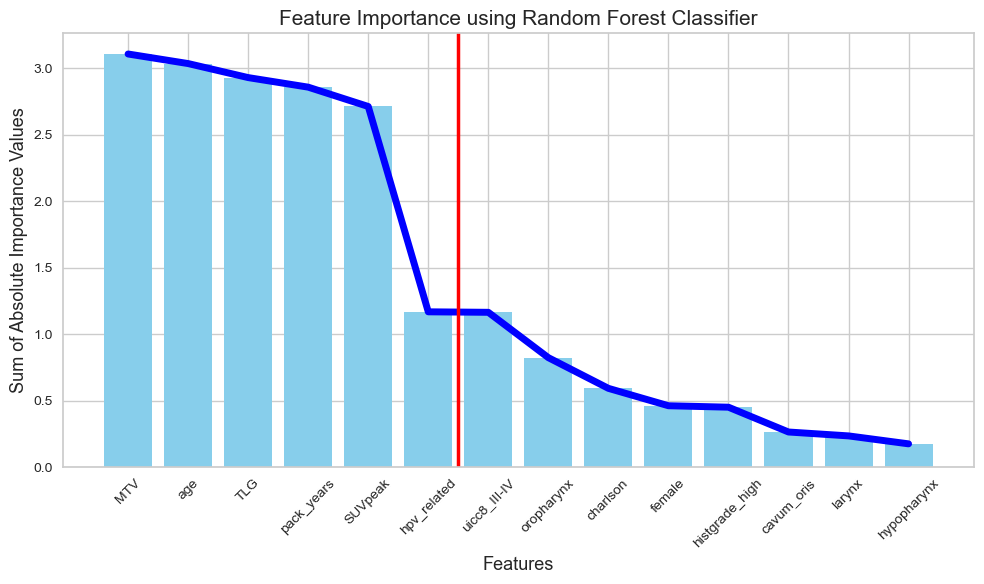

In [18]:
# Plot the bar graph
plt.figure(figsize=(10, 6)) 
plt.bar(df_feature_importances_sorted['Feature'], 
        df_feature_importances_sorted['Importance_Sum'], 
        color='skyblue')
plt.plot(df_feature_importances_sorted['Feature'], 
         df_feature_importances_sorted['Importance_Sum'], 
         color='blue',
        linewidth=5)
plt.xlabel('Features', fontsize=13) 
plt.ylabel('Sum of Absolute Importance Values', fontsize=13) 
plt.title('Feature Importance using Random Forest Classifier', fontsize=15)
plt.xticks(rotation=45) 
plt.axvline(x=5.5, color='red', linestyle='-', linewidth=2.5) 
plt.tight_layout()  
plt.show()

In [21]:
selected_features = df_feature_importances_sorted['Feature'][0:6]

In [22]:
selected_features

12            MTV
0             age
13            TLG
9      pack_years
11        SUVpeak
7     hpv_related
Name: Feature, dtype: object

In [23]:
X_rf = X[selected_features]
X_new = X_rf.copy() 

X_MAASTRO_rf = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_rf.copy()

# Yeo-Johnson Transformation

In [24]:
original_X = X.copy()

In [25]:
# Transform X_new 
# Set the categorical_columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson')
X_new_numeric_transformed = pt.fit_transform(X_new_numeric)

# Create DataFrame with transformed numerical data
X_new_numeric_transformed = pd.DataFrame(X_new_numeric_transformed, 
                                         columns=X_new_numeric.columns, 
                                         index=X_new.index)

# Concatenate transformed numerical data with categorical data
X_new_std = pd.concat([X_new_numeric_transformed, X_new_categoric], axis=1)

# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the transformation for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = pt.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [26]:
X_new

,MTV,age,TLG,pack_years,SUVpeak,hpv_related
0,7.934,54.238356,86.228420,0.000000,14.473272,0.0
1,1.656,54.539726,7.040100,27.404795,5.044678,0.0
2,14.502,59.019178,83.569669,41.019178,7.839043,0.0
3,2.440,70.726027,5.567091,37.500000,2.880631,0.0
4,3.668,67.865753,16.150550,53.000000,5.402006,0.0
...,...,...,...,...,...,...
134,3.650,60.435616,26.280140,0.000000,9.290139,1.0
135,18.967,68.794521,101.754834,0.000000,7.172883,1.0
136,6.370,57.498630,66.273201,39.498630,13.873187,1.0
137,12.443,65.684932,71.832443,71.527397,7.507419,1.0


In [27]:
X_new_std

,MTV,age,TLG,pack_years,SUVpeak,hpv_related
0,0.080033,-0.785036,0.343545,-1.533345,0.750782,0.0
1,-1.722060,-0.746998,-1.657833,0.397233,-1.213660,0.0
2,0.735716,-0.175256,0.318631,0.830437,-0.474112,0.0
3,-1.291020,1.371631,-1.835650,0.727938,-1.992620,0.0
4,-0.816679,0.987008,-1.003396,1.144253,-1.106304,0.0
...,...,...,...,...,...,...
134,-0.822461,0.007949,-0.611074,-1.533345,-0.158214,1.0
135,1.008070,1.111443,0.474941,-1.533345,-0.632361,1.0
136,-0.170908,-0.370651,0.133612,0.786825,0.658564,1.0
137,0.574668,0.696583,0.197985,1.554125,-0.551725,1.0


In [28]:
MAASTRO_new

,MTV,age,TLG,pack_years,SUVpeak,hpv_related
0,22.841,55,263.611623,0,15.438583,1
1,5.660,55,36.980700,20,8.829353,0
2,7.791,55,74.636342,6,13.476123,0
3,7.908,61,46.791979,45,8.632732,0
4,15.237,70,107.637514,59,9.783954,1
...,...,...,...,...,...,...
94,6.110,66,144.490782,55,31.338410,0
95,7.182,63,69.214868,174,13.041604,0
96,16.483,63,102.594274,0,8.944517,1
97,9.981,54,103.229492,0,14.184236,1


In [29]:
MAASTRO_new_std

,MTV,age,TLG,pack_years,SUVpeak,hpv_related
0,1.188930,-0.688798,1.218887,-1.533345,0.893634,1
1,-0.307894,-0.688798,-0.335276,0.104884,-0.254678,0
2,0.059450,-0.688798,0.228548,-0.713198,0.595996,0
3,0.076321,0.081262,-0.145668,0.940197,-0.296877,0
4,0.786849,1.273609,0.519421,1.285347,-0.058378,1
...,...,...,...,...,...,...
94,-0.219083,0.738387,0.751363,1.192311,2.645651,0
95,-0.033134,0.342484,0.168333,3.094727,0.526028,0
96,0.867254,0.342484,0.481447,-1.533345,-0.230255,1
97,0.336049,-0.815082,0.486335,-1.533345,0.706707,1


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [30]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:40:23,633] A new study created in memory with name: no-name-465bf7db-d2fc-4a5e-8c10-13e3a5e68d67


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6175298804780877
Fold 2 C-index: 0.6472868217054264
Fold 3 C-index: 0.6808510638297872
Fold 4 C-index: 0.6958174904942965


[I 2024-04-13 17:40:38,810] A new study created in memory with name: no-name-7c28093e-cfb6-4e18-a489-97b73bd6deea


Fold 5 C-index: 0.5579399141630901
[I 2024-04-13 17:40:38,782] Trial 0 finished with value: 0.6398850341341376 and parameters: {}. Best is trial 0 with value: 0.6398850341341376.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6398850341341376], datetime_start=datetime.datetime(2024, 4, 13, 17, 40, 23, 871599), datetime_complete=datetime.datetime(2024, 4, 13, 17, 40, 38, 781155), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6398850341341376


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.22793001344244193
Fold 2 IBS: 0.21690529506798525
Fold 3 IBS: 0.22116773854120875
Fold 4 IBS: 0.23759745554818645
Fold 5 IBS: 0.22916109524086897
[I 2024-04-13 17:40:40,125] Trial 0 finished with value: 0.22655231956813826 and parameters: {}. Best is trial 0 with value: 0.22655231956813826.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.22655231956813826], datetime_start=datetime.datetime(2024, 4, 13, 17, 40, 38, 854343), datetime_complete=datetime.datetime(2024, 4, 13, 17, 40, 40, 125056), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.22655231956813826


In [31]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [32]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.64
train_ibs:  0.227


#### Test

In [33]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [34]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.597
IBS score: 0.269


In [35]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [36]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [37]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:40:40,471] A new study created in memory with name: no-name-399e7370-7598-4c81-ab8b-45ae7b53769f


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6115537848605578
Fold 2 C-index: 0.5058139534883721
Fold 3 C-index: 0.5617021276595745


[I 2024-04-13 17:40:41,366] A new study created in memory with name: no-name-44f2867c-57cd-4178-92ae-b1397becaf1c


Fold 4 C-index: 0.48859315589353614
Fold 5 C-index: 0.6201716738197425
[I 2024-04-13 17:40:41,350] Trial 0 finished with value: 0.5575669391443565 and parameters: {}. Best is trial 0 with value: 0.5575669391443565.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5575669391443565], datetime_start=datetime.datetime(2024, 4, 13, 17, 40, 40, 611974), datetime_complete=datetime.datetime(2024, 4, 13, 17, 40, 41, 349800), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5575669391443565


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2472470976502871
Fold 2 IBS: 0.23203988447801246
Fold 3 IBS: 0.2289818653708319
Fold 4 IBS: 0.24197477788346888
Fold 5 IBS: 0.22939558812376074
[I 2024-04-13 17:40:42,163] Trial 0 finished with value: 0.23592784270127223 and parameters: {}. Best is trial 0 with value: 0.23592784270127223.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592784270127223], datetime_start=datetime.datetime(2024, 4, 13, 17, 40, 41, 541699), datetime_complete=datetime.datetime(2024, 4, 13, 17, 40, 42, 163172), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592784270127223


In [38]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [39]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.558
train_ibs:  0.236


#### Test

In [40]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [41]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.53


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [42]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [43]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:40:42,657] A new study created in memory with name: no-name-a805dde1-affa-4c28-afd7-45da2833bb65


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6175298804780877
Fold 2 C-index: 0.6395348837209303
Fold 3 C-index: 0.6851063829787234
Fold 4 C-index: 0.6768060836501901


[I 2024-04-13 17:40:43,937] A new study created in memory with name: no-name-fbca5f01-16ce-4d59-9ac0-2c98112d358e


Fold 5 C-index: 0.5579399141630901
[I 2024-04-13 17:40:43,916] Trial 0 finished with value: 0.6353834289982043 and parameters: {}. Best is trial 0 with value: 0.6353834289982043.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6353834289982043], datetime_start=datetime.datetime(2024, 4, 13, 17, 40, 42, 692039), datetime_complete=datetime.datetime(2024, 4, 13, 17, 40, 43, 915072), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6353834289982043


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.22872920971671046
Fold 2 IBS: 0.21862515287518194
Fold 3 IBS: 0.2172969473237923
Fold 4 IBS: 0.23931855518620468
Fold 5 IBS: 0.2278418127392161
[I 2024-04-13 17:40:45,220] Trial 0 finished with value: 0.2263623355682211 and parameters: {}. Best is trial 0 with value: 0.2263623355682211.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2263623355682211], datetime_start=datetime.datetime(2024, 4, 13, 17, 40, 43, 977467), datetime_complete=datetime.datetime(2024, 4, 13, 17, 40, 45, 220508), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2263623355682211


In [44]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [45]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.635
train_ibs:  0.226


#### Test

In [46]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [47]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.612


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.252


In [48]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [49]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:40:45,881] A new study created in memory with name: no-name-fb697a8f-ad4f-460a-9d8b-9967d5705515


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6175298804780877
Fold 2 C-index: 0.6395348837209303
Fold 3 C-index: 0.6851063829787234
Fold 4 C-index: 0.6730038022813688
Fold 5 C-index: 0.5579399141630901
[I 2024-04-13 17:40:47,855] Trial 0 finished with value: 0.6346229727244401 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.6346229727244401.
Fold 1 C-index: 0.6175298804780877
Fold 2 C-index: 0.6395348837209303
Fold 3 C-index: 0.6808510638297872
Fold 4 C-index: 0.6730038022813688
Fold 5 C-index: 0.5579399141630901
[I 2024-04-13 17:40:49,038] Trial 1 finished with value: 0.6337719088946528 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.6346229727244401.
Fold 1 C-index: 0.6175298804780877
Fold 2 C-index: 0.49806201550387597
Fold 3 C-index: 0.6851063829787234
Fold 4 C-index: 0.6692015209125475
Fold 5 C-index: 0.5579399141630901
[I 2024-04-13 17:40:50,466] Trial 2 finished with value: 0.6055679428072649 and parameters: {'l1_ratio': 0.22692876841884668}

Fold 2 C-index: 0.6434108527131783
Fold 3 C-index: 0.6851063829787234
Fold 4 C-index: 0.6730038022813688
Fold 5 C-index: 0.5579399141630901
[I 2024-04-13 17:41:16,645] Trial 24 finished with value: 0.6353981665228897 and parameters: {'l1_ratio': 0.7805647035680947}. Best is trial 24 with value: 0.6353981665228897.
Fold 1 C-index: 0.6175298804780877
Fold 2 C-index: 0.6434108527131783
Fold 3 C-index: 0.6851063829787234
Fold 4 C-index: 0.6730038022813688
Fold 5 C-index: 0.5579399141630901
[I 2024-04-13 17:41:17,656] Trial 25 finished with value: 0.6353981665228897 and parameters: {'l1_ratio': 0.7759976184978444}. Best is trial 24 with value: 0.6353981665228897.
Fold 1 C-index: 0.6175298804780877
Fold 2 C-index: 0.6356589147286822
Fold 3 C-index: 0.6851063829787234
Fold 4 C-index: 0.6730038022813688
Fold 5 C-index: 0.5579399141630901
[I 2024-04-13 17:41:18,986] Trial 26 finished with value: 0.6338477789259904 and parameters: {'l1_ratio': 0.6161461468561824}. Best is trial 24 with value: 0.

Fold 1 C-index: 0.6135458167330677
Fold 2 C-index: 0.6395348837209303
Fold 3 C-index: 0.6851063829787234
Fold 4 C-index: 0.6730038022813688
Fold 5 C-index: 0.5579399141630901
[I 2024-04-13 17:41:50,005] Trial 48 finished with value: 0.6338261599754361 and parameters: {'l1_ratio': 0.6491328069307203}. Best is trial 24 with value: 0.6353981665228897.
Fold 1 C-index: 0.601593625498008
Fold 2 C-index: 0.49806201550387597
Fold 3 C-index: 0.5553191489361702
Fold 4 C-index: 0.49049429657794674
Fold 5 C-index: 0.6223175965665236
[I 2024-04-13 17:41:50,545] Trial 49 finished with value: 0.5535573366165049 and parameters: {'l1_ratio': 0.005040986123852953}. Best is trial 24 with value: 0.6353981665228897.
Fold 1 C-index: 0.6175298804780877
Fold 2 C-index: 0.6395348837209303
Fold 3 C-index: 0.6851063829787234
Fold 4 C-index: 0.6730038022813688
Fold 5 C-index: 0.5579399141630901
[I 2024-04-13 17:41:51,868] Trial 50 finished with value: 0.6346229727244401 and parameters: {'l1_ratio': 0.556147470734

...

Fold 1 IBS: 0.22888770075076328
Fold 2 IBS: 0.21854288909373715
Fold 3 IBS: 0.21717076538931018
Fold 4 IBS: 0.23948327345725406
Fold 5 IBS: 0.22777607400881358
[I 2024-04-13 17:42:59,083] Trial 0 finished with value: 0.22637214053997562 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.22637214053997562.
Fold 1 IBS: 0.22921770843007158
Fold 2 IBS: 0.21850784718471475
Fold 3 IBS: 0.2164663777739513
Fold 4 IBS: 0.23971431767928542
Fold 5 IBS: 0.22787795992521245
[I 2024-04-13 17:43:00,553] Trial 1 finished with value: 0.2263568421986471 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.2263568421986471.
Fold 1 IBS: 0.22926127103136595
Fold 2 IBS: 0.2325812298093743
Fold 3 IBS: 0.21565033021830854
Fold 4 IBS: 0.23973836308608695
Fold 5 IBS: 0.22787728867135798
[I 2024-04-13 17:43:02,164] Trial 2 finished with value: 0.22902169656329874 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 1 with value: 0.2263568421986

Fold 1 IBS: 0.22895752006622314
Fold 2 IBS: 0.2185457886227176
Fold 3 IBS: 0.21712396318818938
Fold 4 IBS: 0.2395447644741331
Fold 5 IBS: 0.2277686999306222
[I 2024-04-13 17:43:34,889] Trial 25 finished with value: 0.22638814725637707 and parameters: {'l1_ratio': 0.5909863447755366}. Best is trial 14 with value: 0.22633666615824208.
Fold 1 IBS: 0.22915528103908261
Fold 2 IBS: 0.21851333591346547
Fold 3 IBS: 0.21707502383699226
Fold 4 IBS: 0.23967397804907392
Fold 5 IBS: 0.22786936956331377
[I 2024-04-13 17:43:36,743] Trial 26 finished with value: 0.22645739768038564 and parameters: {'l1_ratio': 0.3527001258697712}. Best is trial 14 with value: 0.22633666615824208.
Fold 1 IBS: 0.22903498831710292
Fold 2 IBS: 0.21852534547026065
Fold 3 IBS: 0.21708382827410536
Fold 4 IBS: 0.23959669926458801
Fold 5 IBS: 0.22775645904193287
[I 2024-04-13 17:43:38,299] Trial 27 finished with value: 0.22639946407359796 and parameters: {'l1_ratio': 0.4895460774328857}. Best is trial 14 with value: 0.22633666

Fold 5 IBS: 0.22781929776630208
[I 2024-04-13 17:44:10,756] Trial 49 finished with value: 0.2263495495065587 and parameters: {'l1_ratio': 0.8912622545748322}. Best is trial 46 with value: 0.22632776032243518.
Fold 1 IBS: 0.2287516411247697
Fold 2 IBS: 0.21862491956813992
Fold 3 IBS: 0.2172209028178482
Fold 4 IBS: 0.239364792848484
Fold 5 IBS: 0.2278332489467383
[I 2024-04-13 17:44:13,943] Trial 50 finished with value: 0.226359101061196 and parameters: {'l1_ratio': 0.9307036424480208}. Best is trial 46 with value: 0.22632776032243518.
Fold 1 IBS: 0.22877145803265206
Fold 2 IBS: 0.2185701619892668
Fold 3 IBS: 0.21726709670431937
Fold 4 IBS: 0.23936742385071233
Fold 5 IBS: 0.22778906909407484
[I 2024-04-13 17:44:16,263] Trial 51 finished with value: 0.22635304193420508 and parameters: {'l1_ratio': 0.8768560781719461}. Best is trial 46 with value: 0.22632776032243518.
Fold 1 IBS: 0.2287623795785735
Fold 2 IBS: 0.218620231680049
Fold 3 IBS: 0.21722757571802032
Fold 4 IBS: 0.2393662170810208

Fold 1 IBS: 0.22875707289302236
Fold 2 IBS: 0.21862254628861733
Fold 3 IBS: 0.21731448462675515
Fold 4 IBS: 0.23936551282614685
Fold 5 IBS: 0.2277993411938924
[I 2024-04-13 17:45:03,064] Trial 74 finished with value: 0.22637179156568682 and parameters: {'l1_ratio': 0.9153131326527664}. Best is trial 46 with value: 0.22632776032243518.
Fold 1 IBS: 0.22873055164168196
Fold 2 IBS: 0.21862451551666182
Fold 3 IBS: 0.21726777682362036
Fold 4 IBS: 0.2393187534823554
Fold 5 IBS: 0.2278353773030464
[I 2024-04-13 17:45:04,161] Trial 75 finished with value: 0.2263553949534732 and parameters: {'l1_ratio': 0.9955723488743413}. Best is trial 46 with value: 0.22632776032243518.
Fold 1 IBS: 0.22874192362634455
Fold 2 IBS: 0.2186291757753187
Fold 3 IBS: 0.21722614058028797
Fold 4 IBS: 0.2393635070223441
Fold 5 IBS: 0.22782256514039478
[I 2024-04-13 17:45:05,323] Trial 76 finished with value: 0.226356662428938 and parameters: {'l1_ratio': 0.959535520516864}. Best is trial 46 with value: 0.22632776032243

Fold 5 IBS: 0.227902165983536
[I 2024-04-13 17:45:35,101] Trial 98 finished with value: 0.22644818217975243 and parameters: {'l1_ratio': 0.3410246190042779}. Best is trial 46 with value: 0.22632776032243518.
Fold 1 IBS: 0.22887769230706084
Fold 2 IBS: 0.21854863651660608
Fold 3 IBS: 0.21728422830817212
Fold 4 IBS: 0.23945027896945803
Fold 5 IBS: 0.22781600564957746
[I 2024-04-13 17:45:36,805] Trial 99 finished with value: 0.22639536835017487 and parameters: {'l1_ratio': 0.7168739556534268}. Best is trial 46 with value: 0.22632776032243518.


* Best trial for IBS: 
 FrozenTrial(number=46, state=TrialState.COMPLETE, values=[0.22632776032243518], datetime_start=datetime.datetime(2024, 4, 13, 17, 44, 3, 700638), datetime_complete=datetime.datetime(2024, 4, 13, 17, 44, 5, 212559), params={'l1_ratio': 0.8850783665645852}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=46, value=None)


In [50]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [51]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.635
train_ibs:  0.226


#### Test

In [52]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [53]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.7805647035680947)

test_cindex : 0.602


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.8850783665645852)

test_ibs:  0.252


In [54]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [55]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:45:37,924] A new study created in memory with name: no-name-b619c306-f327-44a3-9d65-0f6995619d4c


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6434262948207171
Fold 2 C-index: 0.6162790697674418
Fold 3 C-index: 0.6170212765957447
Fold 4 C-index: 0.6653992395437263
Fold 5 C-index: 0.5643776824034334
[I 2024-04-13 17:45:48,618] Trial 0 finished with value: 0.6213007126262127 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.6213007126262127.
Fold 1 C-index: 0.545816733067729
Fold 2 C-index: 0.624031007751938
Fold 3 C-index: 0.6297872340425532
Fold 4 C-index: 0.5931558935361216
Fold 5 C-index: 0.5965665236051502
[I 2024-04-13 17:45:56,799] Trial 1 finished with value: 0.5978714784006984 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'm

Fold 5 C-index: 0.5643776824034334
[I 2024-04-13 17:47:38,927] Trial 15 finished with value: 0.611534199715765 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 5, 'min_samples_leaf': 10, 'max_depth': 7, 'n_estimators': 160, 'oob_score': False, 'max_samples': 0.7287959529274602, 'max_features': None, 'min_weight_fraction_leaf': 0.20648604556011108, 'warm_start': False}. Best is trial 0 with value: 0.6213007126262127.
Fold 1 C-index: 0.6354581673306773
Fold 2 C-index: 0.6201550387596899
Fold 3 C-index: 0.6106382978723405
Fold 4 C-index: 0.6863117870722434
Fold 5 C-index: 0.5815450643776824
[I 2024-04-13 17:47:43,819] Trial 16 finished with value: 0.6268216710825267 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 14, 'min_samples_leaf': 16, 'max_depth': 6, 'n_estimators': 126, 'oob_score': False, 'max_samples': 0.6903812149598512, 'max_features': None, 'min_weight_fraction_leaf': 0.21564544203258088, 'warm_start': False}. Best is trial 16 with value: 0.6268216710825

Fold 1 C-index: 0.5896414342629482
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.720532319391635
Fold 5 C-index: 0.6630901287553648
[I 2024-04-13 17:48:14,341] Trial 31 finished with value: 0.6938841800775692 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 17, 'min_samples_leaf': 15, 'max_depth': 8, 'n_estimators': 164, 'oob_score': True, 'max_samples': 0.9303719370615893, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.278289048945894, 'warm_start': True}. Best is trial 29 with value: 0.7007344899567138.
Fold 1 C-index: 0.5956175298804781
Fold 2 C-index: 0.7093023255813954
Fold 3 C-index: 0.7872340425531915
Fold 4 C-index: 0.7167300380228137
Fold 5 C-index: 0.6630901287553648
[I 2024-04-13 17:48:16,889] Trial 32 finished with value: 0.6943948129586488 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 17, 'min_samples_leaf': 14, 'max_depth': 9, 'n_estimators': 151, 'oob_score': True, 'max_samples': 0.9167389357302455

...

Fold 5 IBS: 0.2108808548908967
[I 2024-04-13 17:59:58,314] Trial 31 finished with value: 0.22354850256034542 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 19, 'min_samples_leaf': 2, 'max_depth': 20, 'n_estimators': 445, 'oob_score': False, 'max_samples': 0.9810978684008269, 'max_features': None, 'min_weight_fraction_leaf': 0.3471522206172699}. Best is trial 12 with value: 0.22349237634202299.
Fold 1 IBS: 0.228505778055699
Fold 2 IBS: 0.22725356013843231
Fold 3 IBS: 0.22591652753761315
Fold 4 IBS: 0.22858934988450832
Fold 5 IBS: 0.2117833952352178
[I 2024-04-13 18:00:19,156] Trial 32 finished with value: 0.2244097221702941 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 17, 'min_samples_leaf': 4, 'max_depth': 20, 'n_estimators': 449, 'oob_score': False, 'max_samples': 0.855423647372739, 'max_features': None, 'min_weight_fraction_leaf': 0.34317540007421327}. Best is trial 12 with value: 0.22349237634202299.
Fold 1 IBS: 0.22311928628373615
Fold 2 IBS: 0.23535817076

Fold 1 IBS: 0.24297626400370317
Fold 2 IBS: 0.2297129729006354
Fold 3 IBS: 0.23066077879878086
Fold 4 IBS: 0.24212236039153795
Fold 5 IBS: 0.22476311949440209
[I 2024-04-13 18:03:48,727] Trial 47 finished with value: 0.2340470991178119 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 19, 'min_samples_leaf': 2, 'max_depth': 20, 'n_estimators': 318, 'oob_score': True, 'max_samples': 0.7815674884446719, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.35084710571526045}. Best is trial 12 with value: 0.22349237634202299.
Fold 1 IBS: 0.2467085665108332
Fold 2 IBS: 0.23212998080487696
Fold 3 IBS: 0.23016314446127314
Fold 4 IBS: 0.24112046491675382
Fold 5 IBS: 0.22965774898083344
[I 2024-04-13 18:03:56,784] Trial 48 finished with value: 0.23595598113491412 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 9, 'min_samples_leaf': 4, 'max_depth': 13, 'n_estimators': 263, 'oob_score': False, 'max_samples': 0.1428225879209601, 'max_features': None, 'min_weight_fraction_lea

Fold 5 IBS: 0.21086208828795835
[I 2024-04-13 18:06:55,136] Trial 62 finished with value: 0.22355626366069142 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 19, 'min_samples_leaf': 2, 'max_depth': 19, 'n_estimators': 402, 'oob_score': False, 'max_samples': 0.9690887621650419, 'max_features': None, 'min_weight_fraction_leaf': 0.3409497785231807}. Best is trial 12 with value: 0.22349237634202299.
Fold 1 IBS: 0.22688647803319123
Fold 2 IBS: 0.22897341384776393
Fold 3 IBS: 0.22574980089332755
Fold 4 IBS: 0.22680312572709857
Fold 5 IBS: 0.21154760148519733
[I 2024-04-13 18:07:08,492] Trial 63 finished with value: 0.22399208399731574 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 18, 'min_samples_leaf': 2, 'max_depth': 20, 'n_estimators': 407, 'oob_score': False, 'max_samples': 0.8929230648948966, 'max_features': None, 'min_weight_fraction_leaf': 0.34094603506502813}. Best is trial 12 with value: 0.22349237634202299.
Fold 1 IBS: 0.2248434168949931
Fold 2 IBS: 0.2298

Fold 1 IBS: 0.23666199244501102
Fold 2 IBS: 0.2222377140179789
Fold 3 IBS: 0.2255776005487389
Fold 4 IBS: 0.23979017912438952
Fold 5 IBS: 0.22014473784899546
[I 2024-04-13 18:10:58,922] Trial 78 finished with value: 0.22888244479702274 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 16, 'min_samples_leaf': 4, 'max_depth': 14, 'n_estimators': 390, 'oob_score': False, 'max_samples': 0.9147835512625551, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.2860580526524515}. Best is trial 12 with value: 0.22349237634202299.
Fold 1 IBS: 0.2322305950977297
Fold 2 IBS: 0.22354944885593056
Fold 3 IBS: 0.22788341579300325
Fold 4 IBS: 0.23139194029125296
Fold 5 IBS: 0.21432080594986086
[I 2024-04-13 18:11:03,639] Trial 79 finished with value: 0.22587524119755548 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 20, 'min_samples_leaf': 1, 'max_depth': 15, 'n_estimators': 130, 'oob_score': False, 'max_samples': 0.9407406767552778, 'max_features': None, 'min_weight_fraction_le

Fold 1 IBS: 0.22740985271766276
Fold 2 IBS: 0.22809461072935316
Fold 3 IBS: 0.22580045859094688
Fold 4 IBS: 0.22759457538236308
Fold 5 IBS: 0.21173350484217157
[I 2024-04-13 18:13:44,846] Trial 94 finished with value: 0.2241266004524995 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 19, 'min_samples_leaf': 9, 'max_depth': 19, 'n_estimators': 354, 'oob_score': False, 'max_samples': 0.9096951818368773, 'max_features': None, 'min_weight_fraction_leaf': 0.35573536457337435}. Best is trial 93 with value: 0.2234317535820391.
Fold 1 IBS: 0.22391983768638388
Fold 2 IBS: 0.2310306842540158
Fold 3 IBS: 0.22356931156139767
Fold 4 IBS: 0.22826145252736446
Fold 5 IBS: 0.21116971131336215
[I 2024-04-13 18:14:01,146] Trial 95 finished with value: 0.22359019946850478 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 20, 'min_samples_leaf': 8, 'max_depth': 1, 'n_estimators': 489, 'oob_score': False, 'max_samples': 0.928208565030798, 'max_features': None, 'min_weight_fraction_leaf

In [56]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [57]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.785
train_ibs:  0.223


#### Test

In [58]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [59]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=19, max_leaf_nodes=10,
                     max_samples=0.998932192469635, min_samples_leaf=1,
                     min_samples_split=11,
                     min_weight_fraction_leaf=0.0017251077593720236,
                     n_estimators=374, random_state=123, warm_start=True)

test_cindex:  0.583


RandomSurvivalForest(max_depth=19, max_features=None, max_leaf_nodes=19,
                     max_samples=0.9995144568960213, min_samples_leaf=9,
                     min_samples_split=14,
                     min_weight_fraction_leaf=0.33362376482840916,
                     n_estimators=346, random_state=123)

test_ibs:  0.223


In [60]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [61]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 18:15:14,233] A new study created in memory with name: no-name-d7bb81d5-109e-43bf-a00a-91926508ace3


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6334661354581673
Fold 2 C-index: 0.6937984496124031
Fold 3 C-index: 0.7957446808510639
Fold 4 C-index: 0.7376425855513308
Fold 5 C-index: 0.6351931330472103
[I 2024-04-13 18:15:17,054] Trial 0 finished with value: 0.699168996904035 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.699168996904035.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:15:23,278] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}.

Fold 4 C-index: 0.7262357414448669
Fold 5 C-index: 0.6351931330472103
[I 2024-04-13 18:16:38,007] Trial 15 finished with value: 0.6830265032270603 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 13, 'max_depth': 4, 'n_estimators': 258, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6880212408103346, 'min_weight_fraction_leaf': 0.07884420972256234}. Best is trial 12 with value: 0.7074121305912919.
Fold 1 C-index: 0.6235059760956175
Fold 2 C-index: 0.6395348837209303
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6806083650190115
Fold 5 C-index: 0.6330472103004292
[I 2024-04-13 18:16:41,848] Trial 16 finished with value: 0.6642754572399637 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.8750346354626457, 'min_weight_fraction_leaf': 0.4093818399278544}. Best i

Fold 1 C-index: 0.6434262948207171
Fold 2 C-index: 0.687984496124031
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.7167300380228137
Fold 5 C-index: 0.628755364806867
[I 2024-04-13 18:17:34,789] Trial 30 finished with value: 0.6919749834357367 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 2, 'min_samples_leaf': 3, 'max_depth': 16, 'n_estimators': 272, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.6133098666498142, 'min_weight_fraction_leaf': 0.10409703411944711}. Best is trial 25 with value: 0.7173393539114832.
Fold 1 C-index: 0.6294820717131474
Fold 2 C-index: 0.7093023255813954
Fold 3 C-index: 0.7957446808510639
Fold 4 C-index: 0.7490494296577946
Fold 5 C-index: 0.6781115879828327
[I 2024-04-13 18:17:37,964] Trial 31 finished with value: 0.7123380191572467 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 4, 'min_samples_leaf': 3, 'max_depth': 20, 'n_estimators': 410, 'oob_score': False, 'warm_start': True, 'max_features'

...

Fold 1 IBS: 0.23327182761930912
Fold 2 IBS: 0.22576632343889697
Fold 3 IBS: 0.21826936198889313
Fold 4 IBS: 0.22883438673843534
Fold 5 IBS: 0.21867205490385946
[I 2024-04-13 18:27:07,812] Trial 30 finished with value: 0.2249627909378788 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 18, 'min_samples_leaf': 20, 'max_depth': 7, 'n_estimators': 230, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.8205357772718262, 'min_weight_fraction_leaf': 0.21567168822238536}. Best is trial 22 with value: 0.21802130927339677.
Fold 1 IBS: 0.22338123955329298
Fold 2 IBS: 0.22952512769341757
Fold 3 IBS: 0.20736823493993267
Fold 4 IBS: 0.21828885211615798
Fold 5 IBS: 0.21191912558084575
[I 2024-04-13 18:27:14,040] Trial 31 finished with value: 0.2180965159767294 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 20, 'min_samples_leaf': 18, 'max_depth': 11, 'n_estimators': 164, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples':

Fold 1 IBS: 0.2373205667997051
Fold 2 IBS: 0.2283081337477446
Fold 3 IBS: 0.22664938613124685
Fold 4 IBS: 0.23725249452088387
Fold 5 IBS: 0.22340401240325197
[I 2024-04-13 18:28:36,226] Trial 45 finished with value: 0.23058691872056647 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 17, 'min_samples_leaf': 17, 'max_depth': 7, 'n_estimators': 39, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.43461780730090505, 'min_weight_fraction_leaf': 0.04257117666528555}. Best is trial 22 with value: 0.21802130927339677.
Fold 1 IBS: 0.22265739072297794
Fold 2 IBS: 0.23015066352464095
Fold 3 IBS: 0.20764653650267212
Fold 4 IBS: 0.21722379111581086
Fold 5 IBS: 0.21218335524557025
[I 2024-04-13 18:28:41,831] Trial 46 finished with value: 0.21797234742233443 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 16, 'min_samples_leaf': 13, 'max_depth': 10, 'n_estimators': 129, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples':

Fold 1 IBS: 0.23957907501078
Fold 2 IBS: 0.22932245465855877
Fold 3 IBS: 0.22679769937113203
Fold 4 IBS: 0.23851792248038053
Fold 5 IBS: 0.221970289789429
[I 2024-04-13 18:30:07,934] Trial 60 finished with value: 0.2312374882620561 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 11, 'min_samples_leaf': 1, 'max_depth': 8, 'n_estimators': 216, 'oob_score': False, 'warm_start': False, 'max_features': None, 'max_samples': 0.8407143876788239, 'min_weight_fraction_leaf': 0.401257545596435}. Best is trial 46 with value: 0.21797234742233443.
Fold 1 IBS: 0.2228060274507422
Fold 2 IBS: 0.23004690523663868
Fold 3 IBS: 0.2075658550716992
Fold 4 IBS: 0.2165177524725996
Fold 5 IBS: 0.21237029839394736
[I 2024-04-13 18:30:11,962] Trial 61 finished with value: 0.2178613677251254 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 16, 'min_samples_leaf': 13, 'max_depth': 13, 'n_estimators': 92, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.9251215872

Fold 1 IBS: 0.22321899216662702
Fold 2 IBS: 0.22827513305975553
Fold 3 IBS: 0.20513990485427572
Fold 4 IBS: 0.21786655474372457
Fold 5 IBS: 0.21312873467881213
[I 2024-04-13 18:30:51,298] Trial 75 finished with value: 0.217525863900639 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 19, 'n_estimators': 22, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.8516302875046843, 'min_weight_fraction_leaf': 0.29086704130762725}. Best is trial 75 with value: 0.217525863900639.
Fold 1 IBS: 0.22323988977143383
Fold 2 IBS: 0.2271723460765578
Fold 3 IBS: 0.20981607829829083
Fold 4 IBS: 0.21894829749509664
Fold 5 IBS: 0.2128377051247039
[I 2024-04-13 18:30:52,989] Trial 76 finished with value: 0.2184028633532166 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 13, 'min_samples_leaf': 12, 'max_depth': 19, 'n_estimators': 26, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.86727

Fold 1 IBS: 0.2252099251086399
Fold 2 IBS: 0.22566059997909352
Fold 3 IBS: 0.2112335532608738
Fold 4 IBS: 0.22230757769927909
Fold 5 IBS: 0.2124653460683254
[I 2024-04-13 18:31:31,681] Trial 90 finished with value: 0.21937540042324236 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 13, 'min_samples_leaf': 12, 'max_depth': 16, 'n_estimators': 99, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.8148898761595114, 'min_weight_fraction_leaf': 0.3284683195626012}. Best is trial 75 with value: 0.217525863900639.
Fold 1 IBS: 0.22264171262826402
Fold 2 IBS: 0.22951731950317794
Fold 3 IBS: 0.20735594796653437
Fold 4 IBS: 0.21757376977584808
Fold 5 IBS: 0.21230055698762382
[I 2024-04-13 18:31:36,533] Trial 91 finished with value: 0.21787786137228965 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 14, 'min_samples_leaf': 13, 'max_depth': 14, 'n_estimators': 109, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.879

In [62]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [63]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.75
train_ibs:  0.218


#### Test

In [64]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [65]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=10, max_features=None, max_leaf_nodes=11,
                   max_samples=0.5742390537943783, min_samples_leaf=1,
                   min_samples_split=4,
                   min_weight_fraction_leaf=0.018453123019322896,
                   n_estimators=183, random_state=123, warm_start=True)

C-index score: 0.599


ExtraSurvivalTrees(max_depth=19, max_features=None, max_leaf_nodes=15,
                   max_samples=0.8516302875046843, min_samples_leaf=12,
                   min_samples_split=17,
                   min_weight_fraction_leaf=0.29086704130762725,
                   n_estimators=22, oob_score=True, random_state=123)

IBS: 0.227


In [66]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [67]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 18:31:59,657] A new study created in memory with name: no-name-75f477af-ee5c-4a2c-a07f-1c1d285086cd


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:33:01,868] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:33:35,127] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:49:13,899] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 12 with value: 0.6173796952696502.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:51:08,477] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'squar

Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 19:12:23,181] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 12 with value: 0.6173796952696502.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 19:14:55,190] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446, 'criterion': 'friedman_mse', 'ccp_alpha': 0.11820935501930148, 'min_weight_fraction

...

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:38:13,402] Trial 44 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5628832155203615, 'learning_rate': 0.05692286295358468, 'dropout_rate': 0.683156188511181, 'n_estimators': 343, 'criterion': 'friedman_mse', 'ccp_alpha': 9.07255185322531, 'min_weight_fraction_leaf': 0.21518215373385774, 'max_features': None, 'min_impurity_decrease': 0.00078866474186123, 'validation_fraction': 0.8420815814864784, 'min_samples_split': 3, 'max_leaf_nodes': 11, 'min_samples_leaf': 17, 'max_depth': 10}. Best is trial 22 with value: 0.23567346118351176.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-13 21:38:22,362] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.9436582561003044, 'learning_rate': 0.07482848784358435,

Fold 4 IBS: 0.24063660558641659
Fold 5 IBS: 0.22747995650255498
[I 2024-04-13 21:49:27,311] Trial 55 finished with value: 0.23415218415075198 and parameters: {'subsample': 0.5887322566034815, 'learning_rate': 0.03248154248395621, 'dropout_rate': 0.20419816136861105, 'n_estimators': 357, 'criterion': 'friedman_mse', 'ccp_alpha': 0.036799960796019306, 'min_weight_fraction_leaf': 0.30861253825639257, 'max_features': None, 'min_impurity_decrease': 0.0005802162560770055, 'validation_fraction': 0.4978860670989092, 'min_samples_split': 3, 'max_leaf_nodes': 5, 'min_samples_leaf': 9, 'max_depth': 13}. Best is trial 53 with value: 0.2331831601271191.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:50:34,924] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.48190513355031883, 'learning_rate': 0.030884976740502446, 'dropout_rate': 0.198040

Fold 5 IBS: 0.22939559304809248
[I 2024-04-13 22:19:28,882] Trial 66 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6883221930691388, 'learning_rate': 0.043486677645014335, 'dropout_rate': 0.17314117987651884, 'n_estimators': 300, 'criterion': 'friedman_mse', 'ccp_alpha': 1.392319704490283, 'min_weight_fraction_leaf': 0.3364958462902864, 'max_features': None, 'min_impurity_decrease': 0.0002596209104718211, 'validation_fraction': 0.3924562181388663, 'min_samples_split': 2, 'max_leaf_nodes': 4, 'min_samples_leaf': 7, 'max_depth': 15}. Best is trial 65 with value: 0.23297926724694923.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 22:20:07,314] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6123270626634933, 'learning_rate': 0.03766085593505888, 'dropout_rate': 0.12110767967339542, 'n_estimators': 319, 'c

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 23:31:14,316] Trial 78 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6246097794699133, 'learning_rate': 0.04647316253399379, 'dropout_rate': 0.2683524876236738, 'n_estimators': 390, 'criterion': 'friedman_mse', 'ccp_alpha': 0.9868967429041097, 'min_weight_fraction_leaf': 0.3963858435471036, 'max_features': None, 'min_impurity_decrease': 0.00034235487966359176, 'validation_fraction': 0.6768490350713532, 'min_samples_split': 5, 'max_leaf_nodes': 2, 'min_samples_leaf': 12, 'max_depth': 11}. Best is trial 65 with value: 0.23297926724694923.
Fold 1 IBS: 0.24683346598309594
Fold 2 IBS: 0.23144975210900817
Fold 3 IBS: 0.22864502590566183
Fold 4 IBS: 0.2416677465174805
Fold 5 IBS: 0.2289722532647005
[I 2024-04-13 23:31:52,226] Trial 79 finished with value: 0.23551364875598937 and parameters: {'sub

Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 23:41:05,820] Trial 89 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7062934300236606, 'learning_rate': 0.04049073641133963, 'dropout_rate': 0.10286028062555917, 'n_estimators': 321, 'criterion': 'friedman_mse', 'ccp_alpha': 0.5179367484462377, 'min_weight_fraction_leaf': 0.3812326539458533, 'max_features': None, 'min_impurity_decrease': 0.01806689386438656, 'validation_fraction': 0.43928293695272114, 'min_samples_split': 3, 'max_leaf_nodes': 4, 'min_samples_leaf': 6, 'max_depth': 11}. Best is trial 65 with value: 0.23297926724694923.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 23:42:37,050] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.3053150575440778, 'lea

In [68]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [69]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.623
train_ibs:  0.233


#### Test

In [70]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [71]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.0695282634481813,
                                 dropout_rate=0.6152372144778343,
                                 learning_rate=0.0836800120569818, max_depth=16,
                                 max_features='sqrt', max_leaf_nodes=19,
                                 min_impurity_decrease=2.6208170264338426e-07,
                                 min_samples_leaf=18, min_samples_split=11,
                                 min_weight_fraction_leaf=0.10380942101975069,
                                 n_estimators=197, random_state=123,
                                 subsample=0.36282274054429436,
                                 validation_fraction=0.15633978893581735)

C-index score: 0.616


GradientBoostingSurvivalAnalysis(ccp_alpha=0.0027463880859729187,
                                 dropout_rate=0.16871798720386325,
                                 learning_rate=0.04324945527987548,
                                 max_depth=15, max_leaf_nodes=5,
                                 min_impurity_decrease=0.0005159101285841248,
                                 min_samples_leaf=7, min_samples_split=3,
                                 min_weight_fraction_leaf=0.3355883872029622,
                                 n_estimators=300, random_state=123,
                                 subsample=0.6891090397922855,
                                 validation_fraction=0.4525371458863552)

IBS: 0.225


In [72]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [73]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 00:04:20,084] A new study created in memory with name: no-name-72e2b4e5-beff-4c0c-8ce6-90e0a7dcc83a


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6454183266932271
Fold 2 C-index: 0.49806201550387597
Fold 3 C-index: 0.5553191489361702
Fold 4 C-index: 0.4600760456273764
Fold 5 C-index: 0.6437768240343348
[I 2024-04-14 00:04:24,891] Trial 0 finished with value: 0.5605304721589969 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.5605304721589969.
Fold 1 C-index: 0.649402390438247
Fold 2 C-index: 0.49806201550387597
Fold 3 C-index: 0.5553191489361702
Fold 4 C-index: 0.46387832699619774
Fold 5 C-index: 0.6437768240343348
[I 2024-04-14 00:04:55,567] Trial 1 finished with value: 0.5620877411817651 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.5620877411817651.
Fold 1 C-index: 0.649402390438247
Fold 2 C-index: 0.501937984496124
Fold 3 C-index: 0.5553191489361702
Fold 

Fold 1 C-index: 0.6533864541832669
Fold 2 C-index: 0.5271317829457365
Fold 3 C-index: 0.5617021276595745
Fold 4 C-index: 0.4752851711026616
Fold 5 C-index: 0.6566523605150214
[I 2024-04-14 00:09:41,315] Trial 19 finished with value: 0.5748315792812522 and parameters: {'subsample': 0.19816662555708264, 'dropout_rate': 0.6170255353098466, 'n_estimators': 400, 'learning_rate': 0.08909215792368923}. Best is trial 16 with value: 0.5990771972557187.
Fold 1 C-index: 0.6573705179282868
Fold 2 C-index: 0.5135658914728682
Fold 3 C-index: 0.5446808510638298
Fold 4 C-index: 0.4790874524714829
Fold 5 C-index: 0.6266094420600858
[I 2024-04-14 00:09:50,139] Trial 20 finished with value: 0.5642628309993107 and parameters: {'subsample': 0.38161734041406226, 'dropout_rate': 0.7906239277194107, 'n_estimators': 258, 'learning_rate': 0.06551866052750378}. Best is trial 16 with value: 0.5990771972557187.
Fold 1 C-index: 0.6733067729083665
Fold 2 C-index: 0.5348837209302325
Fold 3 C-index: 0.5829787234042553

Fold 1 C-index: 0.6693227091633466
Fold 2 C-index: 0.5348837209302325
Fold 3 C-index: 0.574468085106383
Fold 4 C-index: 0.5285171102661597
Fold 5 C-index: 0.6866952789699571
[I 2024-04-14 00:34:34,481] Trial 38 finished with value: 0.5987773808872159 and parameters: {'subsample': 0.10052220125797712, 'dropout_rate': 0.3444993866462302, 'n_estimators': 283, 'learning_rate': 0.060236166825768794}. Best is trial 31 with value: 0.61089413809741.
Fold 1 C-index: 0.6573705179282868
Fold 2 C-index: 0.5232558139534884
Fold 3 C-index: 0.5574468085106383
Fold 4 C-index: 0.4714828897338403
Fold 5 C-index: 0.6394849785407726
[I 2024-04-14 00:34:40,581] Trial 39 finished with value: 0.5698082017334052 and parameters: {'subsample': 0.25893748731766264, 'dropout_rate': 0.5293334962865761, 'n_estimators': 175, 'learning_rate': 0.09489795708614977}. Best is trial 31 with value: 0.61089413809741.
Fold 1 C-index: 0.6573705179282868
Fold 2 C-index: 0.5135658914728682
Fold 3 C-index: 0.5553191489361702
Fol

...

Fold 3 IBS: 0.2617604456277803
Fold 4 IBS: 0.30376881725338933
Fold 5 IBS: 0.2004294237546137
[I 2024-04-14 00:50:14,580] Trial 19 finished with value: 0.256766902191982 and parameters: {'subsample': 0.3892284838807411, 'dropout_rate': 0.5557151167602331, 'n_estimators': 135, 'learning_rate': 0.04269105711861253}. Best is trial 13 with value: 0.2352303319583889.
Fold 1 IBS: 0.23961922749507528
Fold 2 IBS: 0.23549019128996035
Fold 3 IBS: 0.22350181521096485
Fold 4 IBS: 0.2569624840254174
Fold 5 IBS: 0.2215925285932415
[I 2024-04-14 00:50:16,281] Trial 20 finished with value: 0.23543324932293186 and parameters: {'subsample': 0.8416818569890604, 'dropout_rate': 0.7018301325895367, 'n_estimators': 61, 'learning_rate': 0.017331004877487094}. Best is trial 13 with value: 0.2352303319583889.
Fold 1 IBS: 0.24041271058313812
Fold 2 IBS: 0.23480536014125583
Fold 3 IBS: 0.22363370200394175
Fold 4 IBS: 0.25546566352719374
Fold 5 IBS: 0.22222959253760438
[I 2024-04-14 00:50:17,232] Trial 21 finishe

Fold 4 IBS: 0.2496870055152563
Fold 5 IBS: 0.21152916395183619
[I 2024-04-14 00:51:15,133] Trial 38 finished with value: 0.23059677331068298 and parameters: {'subsample': 0.16549526632968403, 'dropout_rate': 0.1735152457800938, 'n_estimators': 31, 'learning_rate': 0.0800620865082457}. Best is trial 38 with value: 0.23059677331068298.
Fold 1 IBS: 0.2352482549700227
Fold 2 IBS: 0.23504711005982992
Fold 3 IBS: 0.22342330921996406
Fold 4 IBS: 0.2522560397856276
Fold 5 IBS: 0.2161311235825779
[I 2024-04-14 00:51:16,360] Trial 39 finished with value: 0.23242116752360445 and parameters: {'subsample': 0.30064266321422034, 'dropout_rate': 0.11297208322708788, 'n_estimators': 31, 'learning_rate': 0.06331031607354758}. Best is trial 38 with value: 0.23059677331068298.
Fold 1 IBS: 0.23658528049911215
Fold 2 IBS: 0.2325052716905169
Fold 3 IBS: 0.2215239266531283
Fold 4 IBS: 0.246658643649228
Fold 5 IBS: 0.21762320584541306
[I 2024-04-14 00:51:17,828] Trial 40 finished with value: 0.2309792656674796

Fold 4 IBS: 0.29662989424271646
Fold 5 IBS: 0.19735635637022644
[I 2024-04-14 00:52:24,157] Trial 57 finished with value: 0.25169148981873024 and parameters: {'subsample': 0.2561703045384748, 'dropout_rate': 0.20307624370683014, 'n_estimators': 102, 'learning_rate': 0.06795033768066108}. Best is trial 41 with value: 0.23046494093046527.
Fold 1 IBS: 0.2708795023727447
Fold 2 IBS: 0.3294712577574693
Fold 3 IBS: 0.2921363414801454
Fold 4 IBS: 0.3335424050249942
Fold 5 IBS: 0.20425848822850648
[I 2024-04-14 00:52:37,348] Trial 58 finished with value: 0.28605759897277205 and parameters: {'subsample': 0.18621814867527403, 'dropout_rate': 0.14514956415417343, 'n_estimators': 319, 'learning_rate': 0.0465981817354916}. Best is trial 41 with value: 0.23046494093046527.
Fold 1 IBS: 0.23232246177794819
Fold 2 IBS: 0.24286587113983024
Fold 3 IBS: 0.22449339309085645
Fold 4 IBS: 0.26041720325199125
Fold 5 IBS: 0.21145548179750606
[I 2024-04-14 00:52:40,023] Trial 59 finished with value: 0.2343108822

Fold 4 IBS: 0.26397085404668824
Fold 5 IBS: 0.20324592843677428
[I 2024-04-14 00:53:15,702] Trial 76 finished with value: 0.2374881950535316 and parameters: {'subsample': 0.2021584084093895, 'dropout_rate': 0.17810978795049698, 'n_estimators': 66, 'learning_rate': 0.07133487257822313}. Best is trial 41 with value: 0.23046494093046527.
Fold 1 IBS: 0.24187217878244788
Fold 2 IBS: 0.2322942219652355
Fold 3 IBS: 0.22194802766005475
Fold 4 IBS: 0.24564838862649574
Fold 5 IBS: 0.22258661874157953
[I 2024-04-14 00:53:16,829] Trial 77 finished with value: 0.23286988715516266 and parameters: {'subsample': 0.133287287144831, 'dropout_rate': 0.209829883130696, 'n_estimators': 16, 'learning_rate': 0.07619721161870127}. Best is trial 41 with value: 0.23046494093046527.
Fold 1 IBS: 0.23182334455672832
Fold 2 IBS: 0.2434966430356227
Fold 3 IBS: 0.22869319079284375
Fold 4 IBS: 0.26542375111637556
Fold 5 IBS: 0.21077502568989004
[I 2024-04-14 00:53:18,386] Trial 78 finished with value: 0.23604239103829

Fold 4 IBS: 0.24889601710678427
Fold 5 IBS: 0.20975371171341775
[I 2024-04-14 00:53:45,374] Trial 95 finished with value: 0.2305730400986113 and parameters: {'subsample': 0.1005501086914994, 'dropout_rate': 0.2172630915960287, 'n_estimators': 59, 'learning_rate': 0.05742342110047873}. Best is trial 41 with value: 0.23046494093046527.
Fold 1 IBS: 0.23202613969666666
Fold 2 IBS: 0.23854333480273318
Fold 3 IBS: 0.2232414308537025
Fold 4 IBS: 0.24754710814527545
Fold 5 IBS: 0.20989833329162333
[I 2024-04-14 00:53:47,179] Trial 96 finished with value: 0.23025126935800025 and parameters: {'subsample': 0.10128376455585182, 'dropout_rate': 0.22635601004907177, 'n_estimators': 62, 'learning_rate': 0.050831212169671874}. Best is trial 96 with value: 0.23025126935800025.
Fold 1 IBS: 0.2345202976732919
Fold 2 IBS: 0.24068985018534736
Fold 3 IBS: 0.22024006604458693
Fold 4 IBS: 0.25811092299216093
Fold 5 IBS: 0.20906270656576872
[I 2024-04-14 00:53:49,172] Trial 97 finished with value: 0.2325247686

In [74]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [75]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.612
train_ibs:  0.23


#### Test

In [76]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [77]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.11961990143870348,
                                              learning_rate=0.09489898730582377,
                                              n_estimators=363,
                                              random_state=123,
                                              subsample=0.10116576906277466)

C-index score: 0.577


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.22635601004907177,
                                              learning_rate=0.050831212169671874,
                                              n_estimators=62, random_state=123,
                                              subsample=0.10128376455585182)

IBS: 0.237


In [78]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [79]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.785,1.0
ExtraSurvivalTrees,0.750,2.0
CoxPH,0.640,3.0
CoxLasso,0.635,4.5
CoxElastic,0.635,4.5
GradientBoosting,0.623,6.0
ComponentwiseGradientBoosting,0.612,7.0
CoxRidge,0.558,8.0


In [80]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ExtraSurvivalTrees,0.218,1.0
Randomsurvivalforest,0.223,2.0
CoxLasso,0.226,3.5
CoxElastic,0.226,3.5
CoxPH,0.227,5.0
ComponentwiseGradientBoosting,0.230,6.0
GradientBoosting,0.233,7.0
CoxRidge,0.236,8.0


In [81]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
GradientBoosting,0.616,1.0
CoxLasso,0.612,2.0
CoxElastic,0.602,3.0
ExtraSurvivalTrees,0.599,4.0
CoxPH,0.597,5.0
Randomsurvivalforest,0.583,6.0
ComponentwiseGradientBoosting,0.577,7.0
CoxRidge,0.530,8.0


In [82]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
Randomsurvivalforest,0.223,1.0
GradientBoosting,0.225,2.0
ExtraSurvivalTrees,0.227,3.0
CoxRidge,0.229,4.0
ComponentwiseGradientBoosting,0.237,5.0
CoxLasso,0.252,6.5
CoxElastic,0.252,6.5
CoxPH,0.269,8.0


In [83]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/dfs/yeojohnson/rf/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d1_dfs_yeojohnson_rf_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [84]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-14
